# labcom_retrieve サンプル

LABCOM の `Retrieve.exe` を使って波形を取得します。**LHD の解析サーバーへログイン済みで、LABCOM データへアクセスできることが前提です。** 環境確認セル以外の取得処理は既定で無効です。

In [1]:
import matplotlib.pyplot as plt

from mylhd import LHDRetriever
from mylhd.labcom_retrieve import check_windows_environment

## 1. 実行環境を確認する

In [2]:
environment = check_windows_environment()
for key, value in environment.items():
    print(f"{key}: {value}")

os: Windows
os_version: 10.0.26200
architecture: 64bit
is_windows_compatible: True
retrieve_in_path: False
default_paths_available: ['C:\\LABCOM\\Retrieve\\bin\\Retrieve.exe']


## 2. 取得条件を設定する

自動探索できない場合は `RETRIEVE_DIR` に `Retrieve.exe` を含むディレクトリを指定します。

In [ ]:
RUN_RETRIEVE = False
RETRIEVE_DIR = None  # 例: r"C:\LABCOM\Retrieve\bin"
DIAG = "FMP"
SHOTNO = 139400
SUBSHOT = 1
CHANNEL = 32

## 3. 単一チャンネルを取得・表示する

{'diag_name': 'FMP', 'shot': 139400, 'subshot': 1, 'channel': 32, 'time_axis': True, 'frame_number': None, 'dtype': None, 'Shot': '139400', 'SubShot': '1', 'ChannelNumber': '32', 'ModuleGroup': 'CompactPCI/PXI', 'ModuleType': 'PXI6133', 'DataType': 'RAW', 'Resolution(bit)': '14', 'ImageType': 'INT16', 'DataLength(byte)': '20000000', 'DTSsource': 'FPGA-DTS', 'DTShostID': 'DMODSS54.LHD.nifs.ac.jp', 'DTSmoduleID': 'DMODSS0', 'DTStriggerChannel': 'TRG1', 'CLKsource': 'FPGA-DTS', 'CLKhostID': 'DMODSS54.LHD.nifs.ac.jp', 'CLKmoduleID': 'DMODSS0', 'DTSClockChannel': 'CLK1', 'DTSuserDefinedClock': '0', 'CompressionMethod': 'ZLIB', 'CompLength(byte)': '8256275', 'CRC32': '147631956', 'SignalName': nan, 'SampledFrame': '0', 'FrameByteSize': '0', 'DTShostIDid': '294', 'CLKhostIDid': '294', 'SegSize': '0', 'ManagementVersion': '10.0.0', 'Comment': nan, 'DeviceNumber': '4', 'ProductType': 'PXI-6133', 'SerialNumber': '0x013EA306', 'OnboardMemorySizePerCH': '4194302', 'ChannelNumberInModule': '8', 'Bi

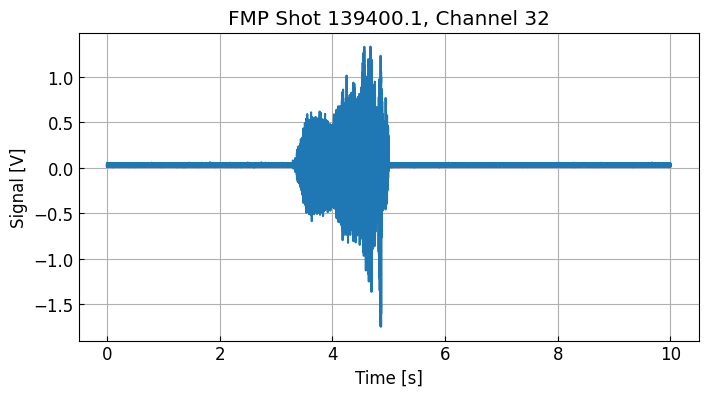

In [4]:
waveform = None

if RUN_RETRIEVE:
    retriever = LHDRetriever(retrieve_path=RETRIEVE_DIR) if RETRIEVE_DIR else LHDRetriever()
    waveform = retriever.retrieve_data(
        diag=DIAG,
        shotno=SHOTNO,
        subshot=SUBSHOT,
        channel=CHANNEL,
        time_axis=True,
    )
    print(waveform.metadata)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(waveform.time, waveform.val)
    ax.set(xlabel="Time [s]", ylabel="Signal [V]", title=waveform.description)
    ax.grid(True)
else:
    print("Retrieval is disabled. Check the settings and set RUN_RETRIEVE=True.")

## 4. 複数チャンネルを取得する

失敗したチャンネルは warning とともにスキップされます。

In [5]:
if RUN_RETRIEVE:
    multi = retriever.retrieve_multiple_channels(
        diag_name=DIAG,
        shot=SHOTNO,
        subshot=SUBSHOT,
        channels=[1, 2, 3, 4],
        time_axis=True,
    )
    for channel, data in multi.items():
        print(channel, data.data.shape, data.data.dtype)

1 (10000000,) int16
2 (10000000,) int16
3 (10000000,) int16
4 (10000000,) int16
